# Comparative Volatility Study  
### Assets: S&P 500 (SPY) vs Bitcoin (BTC)

Objective:  
Compare volatility behaviour between traditional equity markets and cryptocurrency markets using historical daily data.

Dataset:
- SP500 proxy: SPY
- BTC: BTC-USD

Analysis includes:
- Data cleaning
- Log returns calculation
- Volatility estimation
- Distribution analysis

## Step 1 — Load Raw Data

In [16]:
sp500["Date"] = pd.to_datetime(sp500["Date"])
btc["Date"] = pd.to_datetime(btc["Date"])

## Step 2 — Data Cleaning
Removing metadata rows and fixing column structure.

In [19]:
import numpy as np

sp500["log_return"] = np.log(sp500["Close"] / sp500["Close"].shift(1))
btc["log_return"] = np.log(btc["Close"] / btc["Close"].shift(1))

In [20]:
sp500 = sp500.dropna()
btc = btc.dropna()

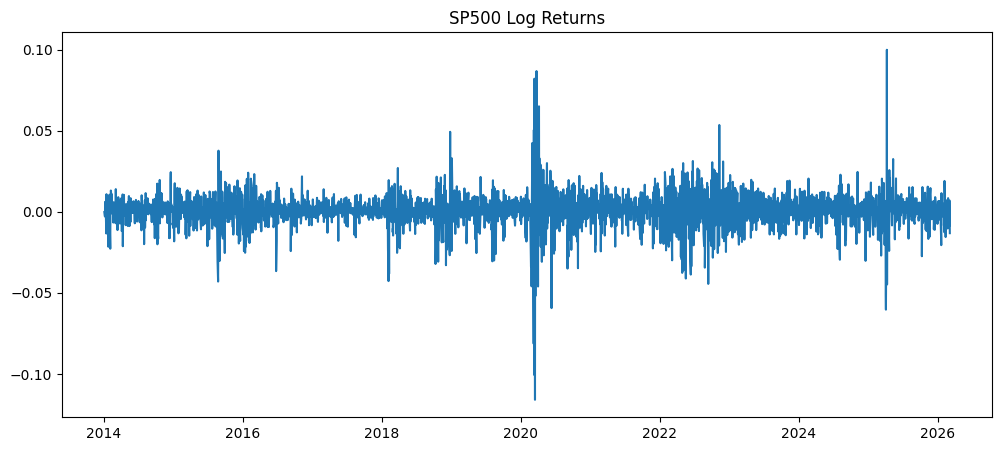

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(sp500.index, sp500["log_return"])
plt.title("SP500 Log Returns")
plt.show()

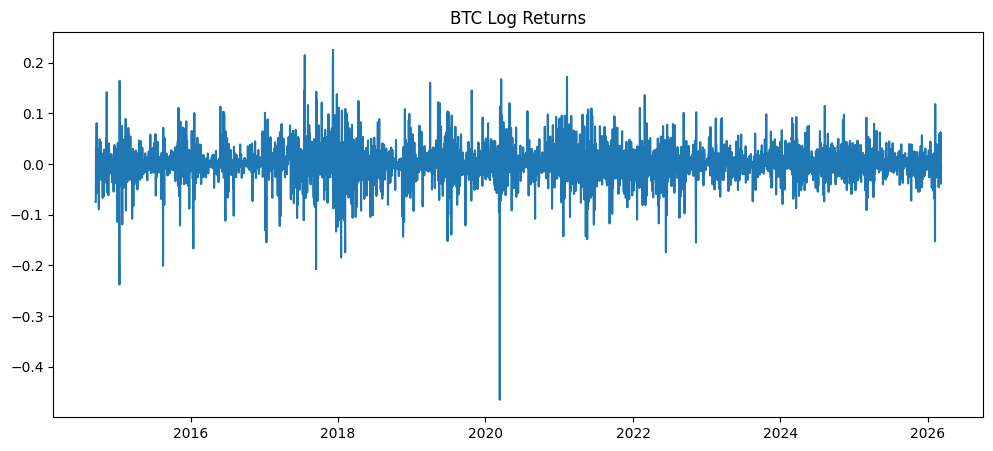

In [23]:
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["log_return"])
plt.title("BTC Log Returns")
plt.show()

In [24]:
sp500["vol_30"] = sp500["log_return"].rolling(30).std()
btc["vol_30"] = btc["log_return"].rolling(30).std()

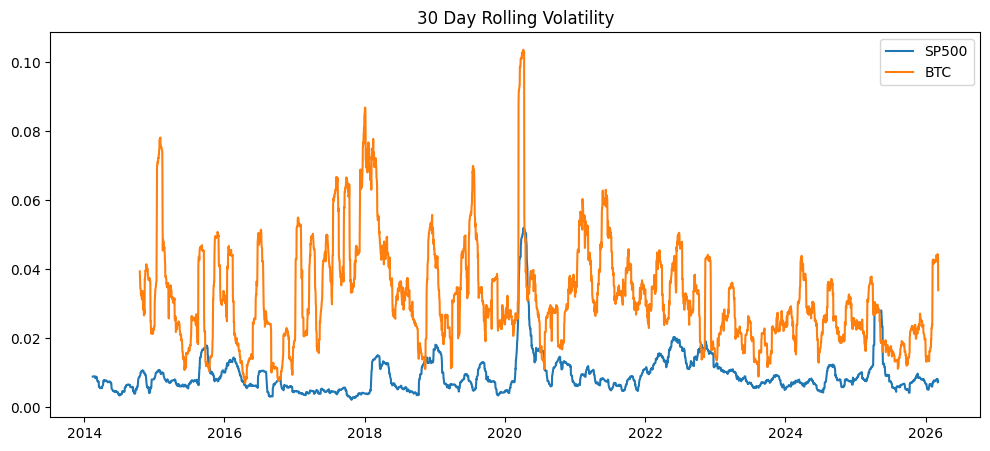

In [25]:
plt.figure(figsize=(12,5))

plt.plot(sp500["vol_30"], label="SP500")
plt.plot(btc["vol_30"], label="BTC")

plt.legend()
plt.title("30 Day Rolling Volatility")
plt.show()

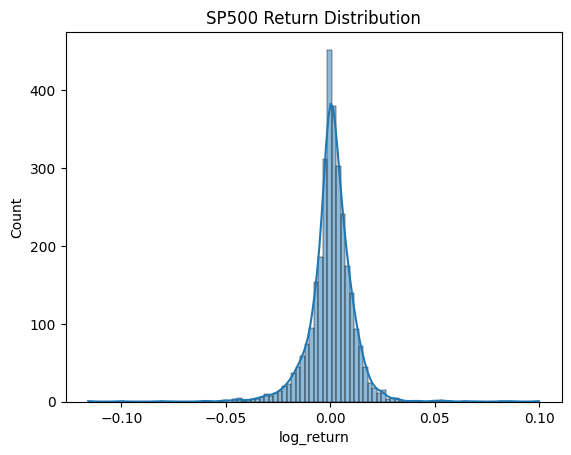

In [26]:
import seaborn as sns

sns.histplot(sp500["log_return"], bins=100, kde=True)
plt.title("SP500 Return Distribution")
plt.show()

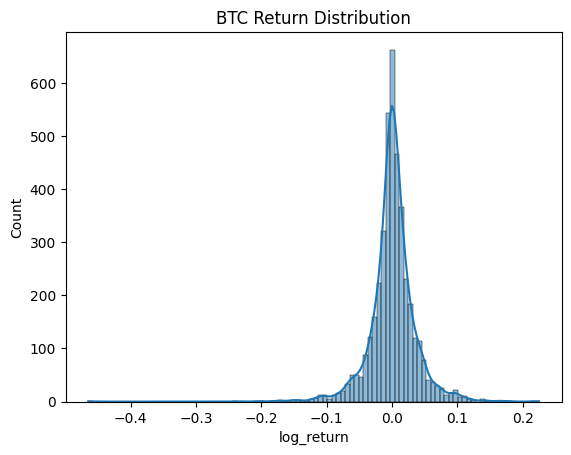

In [27]:
sns.histplot(btc["log_return"], bins=100, kde=True)
plt.title("BTC Return Distribution")
plt.show()

In [28]:
sp500["log_return"].describe()

count    3061.000000
mean        0.000492
std         0.010902
min        -0.115886
25%        -0.003648
50%         0.000655
75%         0.005736
max         0.099863
Name: log_return, dtype: float64

In [29]:
btc["log_return"].describe()

count    4189.000000
mean        0.001194
std         0.035395
min        -0.464730
25%        -0.012673
50%         0.001086
75%         0.015866
max         0.225119
Name: log_return, dtype: float64

In [3]:
print(sp500.head())

        Price               Open                High                 Low  \
0      Ticker                SPY                 SPY                 SPY   
1        Date                NaN                 NaN                 NaN   
2  2014-01-02  149.8494082367519   149.9227215578201  148.62767697479447   
3  2014-01-03  149.2385316363322  149.53990044323353  148.74984662432476   
4  2014-01-06  149.4502818692909    149.507289518721  148.30185177266185   

                Close     Volume  
0                 SPY        SPY  
1                 NaN        NaN  
2  148.98605346679688  119636900  
3  148.96160888671875   81390600  
4   148.5299072265625  108028200  


In [4]:
print(sp500.columns)

Index(['Price', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [5]:
print(btc.head())
print(btc.columns)

        Price               Open                High                Low  \
0      Ticker            BTC-USD             BTC-USD            BTC-USD   
1        Date                NaN                 NaN                NaN   
2  2014-09-17   465.864013671875  468.17401123046875  452.4219970703125   
3  2014-09-18  456.8599853515625   456.8599853515625    413.10400390625   
4  2014-09-19  424.1029968261719   427.8349914550781  384.5320129394531   

                Close    Volume  
0             BTC-USD   BTC-USD  
1                 NaN       NaN  
2   457.3340148925781  21056800  
3  424.44000244140625  34483200  
4   394.7959899902344  37919700  
Index(['Price', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [6]:
sp500 = sp500.reset_index()
btc = btc.reset_index()

In [7]:
sp500.head()

,index,Price,Open,High,Low,Close,Volume
0,0,Ticker,SPY,SPY,SPY,SPY,SPY
1,1,Date,NaN,NaN,NaN,NaN,NaN
2,2,2014-01-02,149.8494082367519,149.9227215578201,148.62767697479447,148.98605346679688,119636900
3,3,2014-01-03,149.2385316363322,149.53990044323353,148.74984662432476,148.96160888671875,81390600
4,4,2014-01-06,149.4502818692909,149.507289518721,148.30185177266185,148.5299072265625,108028200


In [17]:
sp500.set_index("Date", inplace=True)
btc.set_index("Date", inplace=True)

In [18]:
sp500.head()

,Open,High,Low,Close,Volume
Date,,,,,
2014-01-02,149.849408,149.922722,148.627677,148.986053,119636900
2014-01-03,149.238532,149.539900,148.749847,148.961609,81390600
2014-01-06,149.450282,149.507290,148.301852,148.529907,108028200
2014-01-07,149.124474,149.694612,149.010446,149.442123,86144200
2014-01-08,149.417742,149.727251,148.961631,149.474762,96582300


In [9]:
print(sp500.columns)

Index(['index', 'Price', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [10]:
print(btc.columns)

Index(['index', 'Price', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [11]:
sp500 = sp500.reset_index()
btc = btc.reset_index()

sp500.rename(columns={"index": "Date"}, inplace=True)
btc.rename(columns={"index": "Date"}, inplace=True)

In [12]:
print(sp500.head())

   level_0  Date       Price               Open                High  \
0        0     0      Ticker                SPY                 SPY   
1        1     1        Date                NaN                 NaN   
2        2     2  2014-01-02  149.8494082367519   149.9227215578201   
3        3     3  2014-01-03  149.2385316363322  149.53990044323353   
4        4     4  2014-01-06  149.4502818692909    149.507289518721   

                  Low               Close     Volume  
0                 SPY                 SPY        SPY  
1                 NaN                 NaN        NaN  
2  148.62767697479447  148.98605346679688  119636900  
3  148.74984662432476  148.96160888671875   81390600  
4  148.30185177266185   148.5299072265625  108028200  


In [13]:
sp500["Date"] = pd.to_datetime(sp500["Date"])
btc["Date"] = pd.to_datetime(btc["Date"])

sp500.set_index("Date", inplace=True)
btc.set_index("Date", inplace=True)